In [10]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Statistical Analysis
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

# Forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Utilities
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [12]:
from xgboost import XGBRegressor

In [13]:
fuel_df = pd.read_csv('../data/fleet_fuel_weekly.csv')

In [14]:
fuel = fuel_df.copy()

In [15]:
def missing_summary(df):

    report = pd.DataFrame({
        "Missing": df.isnull().sum(),
        "Percent": round(df.isnull().mean()*100,2),
        "Data Type": df.dtypes
    })

    return report

print("Fuel Dataset")
display(missing_summary(fuel))

Fuel Dataset


,Missing,Percent,Data Type
week_start,0,0.00,object
vehicle_id,0,0.00,object
vehicle_type,0,0.00,object
fuel_type,0,0.00,object
gallons,75,3.61,float64
distance_km,75,3.61,float64
engine_hours,0,0.00,float64
avg_speed_kph,0,0.00,float64


In [16]:
fuel["week_start"] = pd.to_datetime(fuel["week_start"])

In [17]:
# =====================================================
# Standardize Text
# =====================================================

text_columns_fuel = [
    "vehicle_id",
    "vehicle_type",
    "fuel_type"
]


for col in text_columns_fuel:

    fuel[col] = (
        fuel[col]
        .str.strip()
        .str.upper()
    )

    
print("Text standardized.")

Text standardized.


In [18]:
# =====================================================
# Check Invalid Values
# =====================================================

print("Fuel records with gallons <= 0")

display(fuel[fuel["gallons"] <= 0])

print("Distance < 0")

display(fuel[fuel["distance_km"] < 0])

print("Engine hours <= 0")

display(fuel[fuel["engine_hours"] <= 0])

print("Average speed <0 or >140")

display(
    fuel[
        (fuel["avg_speed_kph"] < 0) |
        (fuel["avg_speed_kph"] > 140)
    ]
)

Fuel records with gallons <= 0


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph


Distance < 0


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph


Engine hours <= 0


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph


Average speed <0 or >140


,week_start,vehicle_id,vehicle_type,fuel_type,gallons,distance_km,engine_hours,avg_speed_kph


In [19]:
# =====================================================
# Sort Weekly Fuel Data
# =====================================================

fuel = fuel.sort_values(
    by=["vehicle_id", "week_start"]
).reset_index(drop=True)

In [20]:
fuel["gallons"] = fuel.groupby("vehicle_id")["gallons"].ffill()

fuel["distance_km"] = fuel.groupby("vehicle_id")["distance_km"].ffill()

In [21]:
# Fill Remaining Missing Values with Vehicle Median
# =====================================================

fuel["gallons"] = fuel.groupby("vehicle_id")["gallons"].transform(
    lambda x: x.fillna(x.median())
)

fuel["distance_km"] = fuel.groupby("vehicle_id")["distance_km"].transform(
    lambda x: x.fillna(x.median())
)

In [22]:
fuel["gallons"] = fuel["gallons"].fillna(fuel["gallons"].median())
fuel["distance_km"] = fuel["distance_km"].fillna(fuel["distance_km"].median())

In [23]:
print("Fuel Dataset Missing Values")
display(fuel.isnull().sum())

Fuel Dataset Missing Values


week_start       0
vehicle_id       0
vehicle_type     0
fuel_type        0
gallons          0
distance_km      0
engine_hours     0
avg_speed_kph    0
dtype: int64

In [24]:
fuel = fuel.sort_values(
    ["vehicle_id", "week_start"]
).reset_index(drop=True)

In [25]:
# =====================================================
# Aggregate Weekly Fuel Demand
# =====================================================

weekly_fuel = (
    fuel
    .groupby("week_start", as_index=False)["gallons"]
    .sum()
)

display(weekly_fuel.head())

,week_start,gallons
0,2022-01-03,1230.18
1,2022-01-10,1216.21
2,2022-01-17,1250.23
3,2022-01-24,1235.90
4,2022-01-31,1239.72


In [26]:
weekly_fuel = weekly_fuel.set_index("week_start")
weekly_fuel.index = pd.DatetimeIndex(weekly_fuel.index)

display(weekly_fuel.head())

,gallons
week_start,
2022-01-03,1230.18
2022-01-10,1216.21
2022-01-17,1250.23
2022-01-24,1235.90
2022-01-31,1239.72


In [27]:
print("Time Frequency:")
print(pd.infer_freq(weekly_fuel.index))

Time Frequency:
W-MON


TIME SERIRS EXPLORATION

In [28]:
# =====================================================
# Time Series Summary
# =====================================================

print("=" * 60)
print("Weekly Fleet Fuel Demand Summary")
print("=" * 60)

print(f"Start Date       : {weekly_fuel.index.min().date()}")
print(f"End Date         : {weekly_fuel.index.max().date()}")
print(f"Total Weeks      : {len(weekly_fuel)}")
print(f"Average Fuel     : {weekly_fuel['gallons'].mean():.2f} gallons")
print(f"Minimum Fuel     : {weekly_fuel['gallons'].min():.2f} gallons")
print(f"Maximum Fuel     : {weekly_fuel['gallons'].max():.2f} gallons")
print(f"Standard Deviation : {weekly_fuel['gallons'].std():.2f}")

Weekly Fleet Fuel Demand Summary
Start Date       : 2022-01-03
End Date         : 2023-12-25
Total Weeks      : 104
Average Fuel     : 1329.82 gallons
Minimum Fuel     : 1190.21 gallons
Maximum Fuel     : 1458.63 gallons
Standard Deviation : 76.36


In [29]:
fig = px.line(
    weekly_fuel,
    x=weekly_fuel.index,
    y="gallons",
    title="Weekly Fleet Fuel Demand"
)

fig.update_layout(
    xaxis_title="Week",
    yaxis_title="Fuel Consumption (Gallons)",
    template="plotly_white",
    height=500
)

fig.show()

In [30]:
# =====================================================
# Rolling Statistics
# =====================================================

rolling_mean = weekly_fuel["gallons"].rolling(window=4).mean()

rolling_std = weekly_fuel["gallons"].rolling(window=4).std()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=weekly_fuel["gallons"],
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=rolling_mean,
        name="4-Week Rolling Mean"
    )
)

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=rolling_std,
        name="4-Week Rolling Std Dev"
    )
)

fig.update_layout(
    title="Rolling Mean and Standard Deviation",
    template="plotly_white",
    height=500
)

fig.show()

In [31]:
# =====================================================
# Monthly Fuel Trend
# =====================================================

monthly_fuel = (
    weekly_fuel
    .resample("ME")
    .sum()
)

fig = px.bar(
    monthly_fuel,
    x=monthly_fuel.index,
    y="gallons",
    title="Monthly Fleet Fuel Consumption"
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()

In [32]:
# =====================================================
# Moving Averages
# =====================================================

weekly_fuel["MA_4"] = (
    weekly_fuel["gallons"]
    .rolling(4)
    .mean()
)

weekly_fuel["MA_12"] = (
    weekly_fuel["gallons"]
    .rolling(12)
    .mean()
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=weekly_fuel["gallons"],
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=weekly_fuel["MA_4"],
        name="4-Week MA"
    )
)

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=weekly_fuel["MA_12"],
        name="12-Week MA"
    )
)

fig.update_layout(
    title="Short-Term vs Long-Term Moving Averages",
    template="plotly_white",
    height=500
)

fig.show()

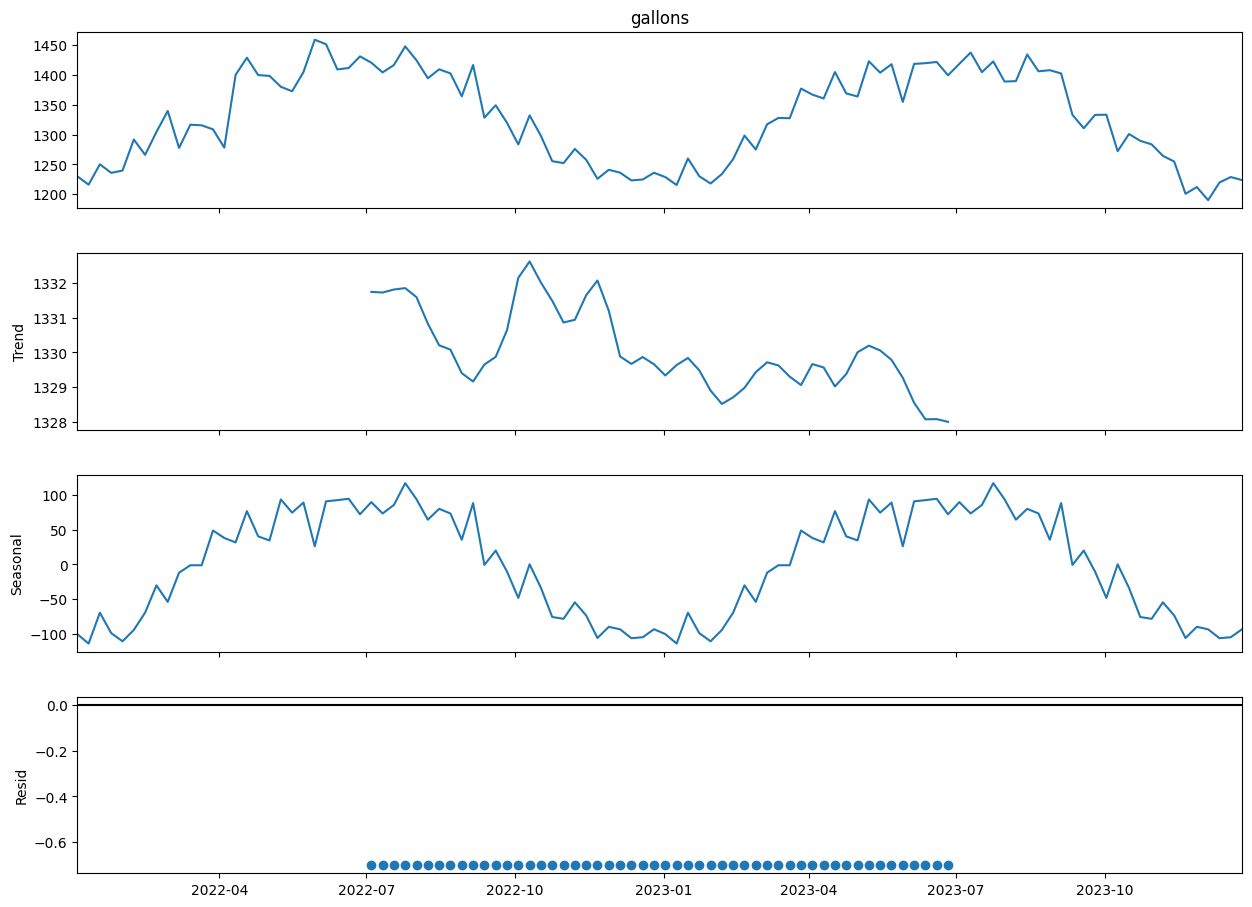

In [33]:
# =====================================================
# Seasonal Decomposition
# =====================================================

decomposition = seasonal_decompose(
    weekly_fuel["gallons"],
    model="additive",
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.show()

In [34]:
# =====================================================
# Monthly Distribution
# =====================================================

monthly_box = weekly_fuel.copy()

monthly_box["Month"] = monthly_box.index.month_name()

fig = px.box(
    monthly_box,
    x="Month",
    y="gallons",
    title="Fuel Demand by Month"
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()

In [35]:
# =====================================================
# Box Plot for Outliers
# =====================================================

fig = px.box(
    weekly_fuel,
    y="gallons",
    title="Weekly Fuel Demand Outlier Detection"
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()


<Figure size 1200x500 with 0 Axes>

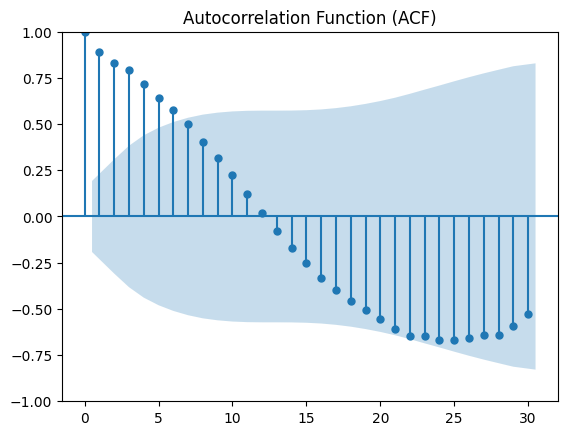

In [36]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))
plot_acf(
    weekly_fuel["gallons"],
    lags=30
)
plt.title("Autocorrelation Function (ACF)")
plt.show()

<Figure size 1200x500 with 0 Axes>

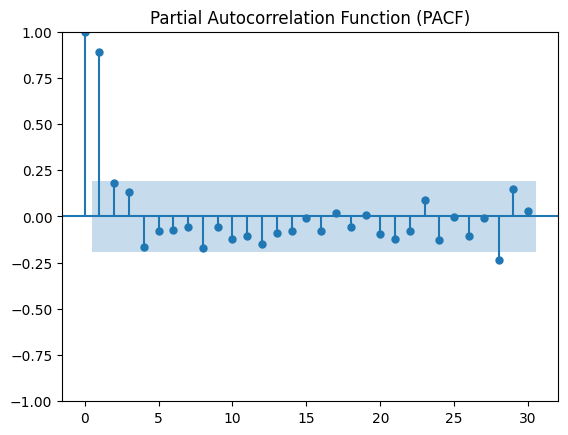

In [37]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 5))
plot_pacf(
    weekly_fuel["gallons"],
    lags=30,
    method="ywm"
)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

STAIONARY TEST

In [38]:
# =====================================================
# Stationarity Visual Check
# =====================================================

rolling_mean = weekly_fuel["gallons"].rolling(window=12).mean()
rolling_std = weekly_fuel["gallons"].rolling(window=12).std()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=weekly_fuel["gallons"],
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=rolling_mean,
        name="12-Week Rolling Mean"
    )
)

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=rolling_std,
        name="12-Week Rolling Std Dev"
    )
)

fig.update_layout(
    title="Stationarity Visual Inspection",
    template="plotly_white",
    height=500
)

fig.show()

In [39]:
# =====================================================
# Augmented Dickey-Fuller Test
# =====================================================

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(weekly_fuel["gallons"])

print("="*60)
print("Augmented Dickey-Fuller Test")
print("="*60)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"P-value       : {adf_result[1]:.6f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

Augmented Dickey-Fuller Test
ADF Statistic : -4.7853
P-value       : 0.000058
Lags Used     : 12
Observations  : 91

Critical Values
1%: -3.5043
5%: -2.8939
10%: -2.5840


In [40]:
# =====================================================
# KPSS Test
# =====================================================

from statsmodels.tsa.stattools import kpss

kpss_result = kpss(
    weekly_fuel["gallons"],
    regression="c",
    nlags="auto"
)

print("="*60)
print("KPSS Test")
print("="*60)

print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"P-value        : {kpss_result[1]:.6f}")
print(f"Lags Used      : {kpss_result[2]}")

print("\nCritical Values")

for key, value in kpss_result[3].items():
    print(f"{key}: {value:.4f}")

KPSS Test
KPSS Statistic : 0.1267
P-value        : 0.100000
Lags Used      : 5

Critical Values
10%: 0.3470
5%: 0.4630
2.5%: 0.5740
1%: 0.7390


In [41]:
# Combined Stationarity Interpretation
# =====================================================

adf_p = adf_result[1]
kpss_p = kpss_result[1]

print("="*60)
print("Stationarity Decision")
print("="*60)

if adf_p < 0.05 and kpss_p > 0.05:
    print("✓ The series is STATIONARY.")
    print("No differencing is required.")

elif adf_p >= 0.05 and kpss_p <= 0.05:
    print("✗ The series is NON-STATIONARY.")
    print("Differencing is recommended.")

else:
    print("⚠ The tests disagree.")
    print("Further investigation is required.")

Stationarity Decision
✓ The series is STATIONARY.
No differencing is required.


FEATURE ENGINEERING FOR FORESACTING

In [42]:
# =====================================================
# Calendar Features
# =====================================================

weekly_fuel["year"] = weekly_fuel.index.year
weekly_fuel["quarter"] = weekly_fuel.index.quarter
weekly_fuel["month"] = weekly_fuel.index.month
weekly_fuel["week"] = weekly_fuel.index.isocalendar().week.astype(int)

print("Calendar features created.")

Calendar features created.


In [43]:
# =====================================================
# Trend Variable
# =====================================================

weekly_fuel["trend"] = np.arange(len(weekly_fuel))

weekly_fuel.head()

,gallons,MA_4,MA_12,year,quarter,month,week,trend
week_start,,,,,,,,
2022-01-03,1230.18,NaN,NaN,2022,1,1,1,0
2022-01-10,1216.21,NaN,NaN,2022,1,1,2,1
2022-01-17,1250.23,NaN,NaN,2022,1,1,3,2
2022-01-24,1235.90,1233.13,NaN,2022,1,1,4,3
2022-01-31,1239.72,1235.51,NaN,2022,1,1,5,4


In [44]:
# =====================================================
# Lag Features
# =====================================================

lags = [1, 2, 4, 8, 12]

for lag in lags:
    weekly_fuel[f"lag_{lag}"] = (
        weekly_fuel["gallons"]
        .shift(lag)
    )

weekly_fuel.head(15)

,gallons,MA_4,MA_12,year,quarter,month,week,trend,lag_1,lag_2,lag_4,lag_8,lag_12
week_start,,,,,,,,,,,,,
2022-01-03,1230.18,NaN,NaN,2022,1,1,1,0,NaN,NaN,NaN,NaN,NaN
2022-01-10,1216.21,NaN,NaN,2022,1,1,2,1,1230.18,NaN,NaN,NaN,NaN
2022-01-17,1250.23,NaN,NaN,2022,1,1,3,2,1216.21,1230.18,NaN,NaN,NaN
2022-01-24,1235.90,1233.13,NaN,2022,1,1,4,3,1250.23,1216.21,NaN,NaN,NaN
2022-01-31,1239.72,1235.51,NaN,2022,1,1,5,4,1235.90,1250.23,1230.18,NaN,NaN
2022-02-07,1291.67,1254.38,NaN,2022,1,2,6,5,1239.72,1235.90,1216.21,NaN,NaN
2022-02-14,1266.02,1258.33,NaN,2022,1,2,7,6,1291.67,1239.72,1250.23,NaN,NaN
2022-02-21,1304.36,1275.44,NaN,2022,1,2,8,7,1266.02,1291.67,1235.90,NaN,NaN
2022-02-28,1339.50,1300.39,NaN,2022,1,2,9,8,1304.36,1266.02,1239.72,1230.18,NaN


In [45]:
# =====================================================
# Rolling Means
# =====================================================

windows = [4, 8, 12]

for window in windows:
    weekly_fuel[f"rolling_mean_{window}"] = (
        weekly_fuel["gallons"]
        .shift(1)
        .rolling(window)
        .mean()
    )

In [46]:
# =====================================================
# Rolling Standard Deviation
# =====================================================

for window in windows:
    weekly_fuel[f"rolling_std_{window}"] = (
        weekly_fuel["gallons"]
        .shift(1)
        .rolling(window)
        .std()
    )

In [47]:
# =====================================================
# Expanding Mean
# =====================================================

weekly_fuel["expanding_mean"] = (
    weekly_fuel["gallons"]
    .shift(1)
    .expanding()
    .mean()
)

In [48]:
# =====================================================
# Weekly Growth Rate
# =====================================================

weekly_fuel["weekly_growth"] = (
    weekly_fuel["gallons"]
    .pct_change()
)

In [49]:
# =====================================================
# Cyclical Features
# =====================================================

weekly_fuel["week_sin"] = np.sin(
    2 * np.pi * weekly_fuel["week"] / 52
)

weekly_fuel["week_cos"] = np.cos(
    2 * np.pi * weekly_fuel["week"] / 52
)

In [50]:
# =====================================================
# Missing Values After Feature Engineering
# =====================================================

missing = (
    weekly_fuel
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

display(missing[missing > 0])

rolling_std_12     12
lag_12             12
rolling_mean_12    12
MA_12              11
lag_8               8
rolling_std_8       8
rolling_mean_8      8
rolling_std_4       4
lag_4               4
rolling_mean_4      4
MA_4                3
lag_2               2
weekly_growth       1
expanding_mean      1
lag_1               1
dtype: int64

In [51]:
# =====================================================
# Remove Rows with Missing Lag Features
# =====================================================

weekly_fuel = weekly_fuel.dropna().copy()

print("Final Dataset Shape:", weekly_fuel.shape)

Final Dataset Shape: (92, 23)


In [52]:
#=====================================================
# Preview Final Dataset
# =====================================================

display(weekly_fuel.head())

print("\nColumns")

print(weekly_fuel.columns.tolist())

,gallons,MA_4,MA_12,year,quarter,month,week,trend,lag_1,lag_2,lag_4,lag_8,lag_12,rolling_mean_4,rolling_mean_8,rolling_mean_12,rolling_std_4,rolling_std_8,rolling_std_12,expanding_mean,weekly_growth,week_sin,week_cos
week_start,,,,,,,,,,,,,,,,,,,,,,,
2022-03-28,1308.69,1304.57,1280.16,2022,1,3,13,12,1315.45,1316.49,1339.50,1239.72,1230.18,1312.27,1293.86,1273.62,25.61,31.95,39.97,1273.62,-0.01,1.00,-0.00
2022-04-04,1278.18,1304.70,1285.32,2022,2,4,14,13,1308.69,1315.45,1277.65,1291.67,1216.21,1304.57,1302.48,1280.16,18.28,23.42,38.62,1276.31,-0.02,0.99,-0.12
2022-04-11,1399.83,1325.54,1297.79,2022,2,4,15,14,1278.18,1308.69,1316.49,1266.02,1250.23,1304.70,1300.79,1285.32,18.02,24.76,33.03,1276.45,0.10,0.97,-0.24
2022-04-18,1428.62,1353.83,1313.85,2022,2,4,16,15,1399.83,1278.18,1315.45,1304.36,1235.90,1325.54,1317.52,1297.79,52.11,39.01,44.74,1284.67,0.02,0.94,-0.35
2022-04-25,1399.45,1376.52,1327.16,2022,2,4,17,16,1428.62,1399.83,1308.69,1339.50,1239.72,1353.83,1333.05,1313.85,71.81,54.63,54.11,1293.67,-0.02,0.89,-0.46



Columns
['gallons', 'MA_4', 'MA_12', 'year', 'quarter', 'month', 'week', 'trend', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'rolling_mean_4', 'rolling_mean_8', 'rolling_mean_12', 'rolling_std_4', 'rolling_std_8', 'rolling_std_12', 'expanding_mean', 'weekly_growth', 'week_sin', 'week_cos']


In [53]:
# =====================================================
# Save Engineered Forecast Dataset
# =====================================================

output_folder = Path("processed_data")
output_folder.mkdir(exist_ok=True)

weekly_fuel.to_csv(
    output_folder / "fuel_forecast_features.csv"
)

print("Forecast feature dataset saved successfully.")

Forecast feature dataset saved successfully.


TRAIN/TEST SPLIT

In [54]:
# =====================================================
# Features and Target
# =====================================================

target = "gallons"

features = [
    "year",
    "quarter",
    "month",
    "week",
    "trend",
    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",
    "lag_12",
    "rolling_mean_4",
    "rolling_mean_8",
    "rolling_mean_12",
    "rolling_std_4",
    "rolling_std_8",
    "rolling_std_12",
    "expanding_mean",
    "weekly_growth",
    "week_sin",
    "week_cos"
]

X = weekly_fuel[features]

y = weekly_fuel[target]

print(f"Number of Features: {len(features)}")
print(f"Target Variable: {target}")

Number of Features: 20
Target Variable: gallons


In [55]:
# =====================================================
# Chronological Train/Test Split
# =====================================================

split_index = int(len(weekly_fuel) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("="*60)
print("Train/Test Split")
print("="*60)

print(f"Training observations : {len(X_train)}")
print(f"Testing observations  : {len(X_test)}")

Train/Test Split
Training observations : 73
Testing observations  : 19


In [56]:
# =====================================================
# Verify Dates
# =====================================================

train_dates = weekly_fuel.index[:split_index]
test_dates = weekly_fuel.index[split_index:]

print("Training Period")
print(train_dates.min())
print(train_dates.max())

print()

print("Testing Period")
print(test_dates.min())
print(test_dates.max())

Training Period
2022-03-28 00:00:00
2023-08-14 00:00:00

Testing Period
2023-08-21 00:00:00
2023-12-25 00:00:00


In [57]:
# =====================================================
# Visualize Train/Test Split
# =====================================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=train_dates,
        y=y_train,
        mode="lines",
        name="Training"
    )
)

fig.add_trace(
    go.Scatter(
        x=test_dates,
        y=y_test,
        mode="lines",
        name="Testing"
    )
)

fig.update_layout(
    title="Chronological Train/Test Split",
    xaxis_title="Week",
    yaxis_title="Fuel Consumption (Gallons)",
    template="plotly_white",
    height=500
)

fig.show()

In [58]:
# =====================================================
# Naïve Forecast
# =====================================================

naive_predictions = y_test.shift(1)

# Replace the first missing prediction with the last observed training value
naive_predictions.iloc[0] = y_train.iloc[-1]

In [59]:
# =====================================================
# Baseline Performance
# =====================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(y_test, naive_predictions)
rmse = np.sqrt(mean_squared_error(y_test, naive_predictions))
mape = mean_absolute_percentage_error(y_test, naive_predictions) * 100

print("="*60)
print("Naïve Forecast Performance")
print("="*60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

Naïve Forecast Performance
MAE  : 21.91
RMSE : 29.29
MAPE : 1.72%


In [60]:
# =====================================================
# Baseline Forecast Plot
# =====================================================

comparison = pd.DataFrame({
    "Actual": y_test,
    "Naive Forecast": naive_predictions
})

fig = px.line(
    comparison,
    title="Baseline (Naïve) Forecast vs Actual"
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()

In [61]:
# =====================================================
# Model Evaluation Function
# =====================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

results = []

def evaluate_model(model_name, actual, predicted):
    """
    Evaluate forecasting model performance.
    """

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    })

    print("="*60)
    print(model_name)
    print("="*60)
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")

    return mae, rmse, mape

In [62]:
# =====================================================
# Holt-Winters Model
# =====================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal=None,   # change to "add" later if strong seasonality exists
    initialization_method="estimated"
)

hw_fit = hw_model.fit()

hw_predictions = hw_fit.forecast(len(y_test))

In [63]:
evaluate_model(
    "Holt-Winters",
    y_test,
    hw_predictions
)

Holt-Winters
MAE  : 116.78
RMSE : 133.29
MAPE : 9.35%


(116.7846943951742, np.float64(133.2907921414543), 9.348520785655559)

In [64]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Prediction": hw_predictions
})

fig = px.line(
    comparison,
    title="Holt-Winters Forecast"
)

fig.show()

In [65]:
# =====================================================
# SARIMA
# =====================================================

sarima = SARIMAX(
    y_train,
    order=(1,0,1),
    seasonal_order=(1,0,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima.fit()

sarima_predictions = sarima_fit.forecast(len(y_test))

In [66]:
evaluate_model(
    "SARIMA",
    y_test,
    sarima_predictions
)

SARIMA
MAE  : 157.57
RMSE : 176.22
MAPE : 12.58%


(157.57237453170387, np.float64(176.220736156064), 12.582311121768466)

In [67]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Prediction": sarima_predictions
})

px.line(
    comparison,
    title="SARIMA Forecast"
).show()

In [68]:
# =====================================================
# Linear Regression
# =====================================================

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_predictions = lr.predict(X_test)

In [69]:
evaluate_model(
    "Linear Regression",
    y_test,
    lr_predictions
)

Linear Regression
MAE  : 1.37
RMSE : 1.83
MAPE : 0.11%


(1.3655750044401167, np.float64(1.831680061501001), 0.10810505258079123)

In [70]:
# =====================================================
# Random Forest
# =====================================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=10
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

In [71]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

Random Forest
MAE  : 17.66
RMSE : 23.86
MAPE : 1.41%


(17.659440435937398, np.float64(23.857071835120895), 1.4085479390395486)

In [72]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

fig = px.bar(
    importance,
    x="Importance",
    y="Feature",
    orientation="h",
    title="Random Forest Feature Importance"
)

fig.show()

In [73]:
# =====================================================
# XGBoost
# =====================================================

from xgboost import XGBRegressor

xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=5,

    random_state=42

)

xgb.fit(X_train, y_train)

xgb_predictions = xgb.predict(X_test)

In [74]:
evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions
)

XGBoost
MAE  : 34.38
RMSE : 42.64
MAPE : 2.74%


(34.3792847964638, np.float64(42.6357025862285), 2.743309031975809)

In [75]:
# =====================================================
# Compare Models
# =====================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "MAPE (%)"
)

display(results_df)

,Model,MAE,RMSE,MAPE (%)
2,Linear Regression,1.37,1.83,0.11
3,Random Forest,17.66,23.86,1.41
4,XGBoost,34.38,42.64,2.74
0,Holt-Winters,116.78,133.29,9.35
1,SARIMA,157.57,176.22,12.58


In [76]:
# =====================================================
# Linear Regression Coefficients
# =====================================================

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    "Abs_Coefficient",
    ascending=False
)

display(coef_df)

,Feature,Coefficient,Abs_Coefficient
17,weekly_growth,1335.51,1335.51
19,week_cos,-4.62,4.62
18,week_sin,-3.27,3.27
5,lag_1,1.00,1.00
2,month,-0.27,0.27
12,rolling_mean_12,-0.05,0.05
3,week,0.04,0.04
15,rolling_std_12,0.03,0.03
10,rolling_mean_4,-0.03,0.03
1,quarter,0.03,0.03


In [77]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": lr_predictions
})

fig = px.line(
    comparison,
    title="Linear Regression: Actual vs Predicted"
)

fig.show()

In [78]:
residuals = y_test - lr_predictions

fig = px.scatter(
    x=lr_predictions,
    y=residuals,
    labels={
        "x": "Predicted Fuel",
        "y": "Residuals"
    },
    title="Residual Plot"
)

fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="red"
)

fig.show()

In [79]:
fig = px.histogram(
    residuals,
    nbins=20,
    title="Residual Distribution"
)

fig.show()

In [80]:
# =====================================================
# Residual Analysis
# =====================================================

residuals = y_test - lr_predictions

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": lr_predictions,
    "Residual": residuals
})

display(comparison.head())


,Actual,Predicted,Residual
week_start,,,
2023-08-21,1405.84,1407.45,-1.61
2023-08-28,1407.68,1406.60,1.08
2023-09-04,1402.24,1400.80,1.44
2023-09-11,1333.00,1334.58,-1.58
2023-09-18,1310.53,1309.65,0.88


In [81]:
fig = px.scatter(
    comparison,
    x="Predicted",
    y="Residual",
    title="Residual Plot"
)

fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="red"
)

fig.update_layout(template="plotly_white")

fig.show()

In [82]:
fig = px.histogram(
    comparison,
    x="Residual",
    nbins=20,
    title="Residual Distribution"
)

fig.update_layout(template="plotly_white")

fig.show()

In [83]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=y_test.index,
        y=y_test,
        mode="lines",
        name="Actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=y_test.index,
        y=lr_predictions,
        mode="lines",
        name="Predicted"
    )
)

fig.update_layout(
    title="Actual vs Predicted Weekly Fuel Demand",
    template="plotly_white",
    xaxis_title="Week",
    yaxis_title="Gallons"
)

fig.show()

In [84]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, lr_predictions)

print("="*60)
print("Model Performance")
print("="*60)

print(f"R² Score : {r2:.4f}")

Model Performance
R² Score : 0.9993


In [85]:
# =====================================================
# Final Model Training
# =====================================================

from sklearn.linear_model import LinearRegression

final_model = LinearRegression()

final_model.fit(X, y)

print("Final model trained successfully.")

Final model trained successfully.


In [86]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": final_model.coef_
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Absolute",
    ascending=False
)

display(coefficients)

,Feature,Coefficient,Absolute
17,weekly_growth,1333.14,1333.14
19,week_cos,-2.37,2.37
18,week_sin,-1.61,1.61
5,lag_1,1.00,1.00
2,month,-0.22,0.22
1,quarter,0.08,0.08
15,rolling_std_12,0.04,0.04
3,week,0.02,0.02
12,rolling_mean_12,-0.02,0.02
13,rolling_std_4,-0.01,0.01


In [87]:
import joblib
from pathlib import Path

model_folder = Path("models")
model_folder.mkdir(exist_ok=True)

joblib.dump(
    final_model,
    model_folder / "fuel_forecast_model.pkl"
)

joblib.dump(
    features,
    model_folder / "forecast_features.pkl"
)

print("Model and feature list saved successfully.")

Model and feature list saved successfully.


In [88]:
# =====================================================
# Recursive Forecast Function
# =====================================================

def recursive_forecast(history_df, model, features, periods=12):
    """
    Recursive multi-step forecast for Linear Regression.
    """

    history = history_df.copy()

    forecasts = []

    for _ in range(periods):

        # Next week
        next_date = history.index[-1] + pd.Timedelta(weeks=1)

        row = {}

        # ------------------------
        # Calendar Features
        # ------------------------

        row["year"] = next_date.year
        row["quarter"] = next_date.quarter
        row["month"] = next_date.month
        row["week"] = int(next_date.isocalendar().week)

        row["trend"] = history["trend"].iloc[-1] + 1

        # ------------------------
        # Lag Features
        # ------------------------

        row["lag_1"] = history["gallons"].iloc[-1]
        row["lag_2"] = history["gallons"].iloc[-2]
        row["lag_4"] = history["gallons"].iloc[-4]
        row["lag_8"] = history["gallons"].iloc[-8]
        row["lag_12"] = history["gallons"].iloc[-12]

        # ------------------------
        # Rolling Mean
        # ------------------------

        row["rolling_mean_4"] = history["gallons"].iloc[-4:].mean()
        row["rolling_mean_8"] = history["gallons"].iloc[-8:].mean()
        row["rolling_mean_12"] = history["gallons"].iloc[-12:].mean()

        # ------------------------
        # Rolling Std
        # ------------------------

        row["rolling_std_4"] = history["gallons"].iloc[-4:].std()
        row["rolling_std_8"] = history["gallons"].iloc[-8:].std()
        row["rolling_std_12"] = history["gallons"].iloc[-12:].std()

        # ------------------------
        # Expanding Mean
        # ------------------------

        row["expanding_mean"] = history["gallons"].mean()

        # ------------------------
        # Weekly Growth
        # ------------------------

        row["weekly_growth"] = (
            history["gallons"].iloc[-1]
            - history["gallons"].iloc[-2]
        ) / history["gallons"].iloc[-2]

        # ------------------------
        # Cyclical Features
        # ------------------------

        row["week_sin"] = np.sin(
            2*np.pi*row["week"]/52
        )

        row["week_cos"] = np.cos(
            2*np.pi*row["week"]/52
        )

        # ------------------------
        # Prediction
        # ------------------------

        X_future = pd.DataFrame([row])[features]

        prediction = model.predict(X_future)[0]

        row["gallons"] = prediction

        forecasts.append(
            {
                "week_start": next_date,
                "forecast_gallons": prediction
            }
        )

        history.loc[next_date] = row

    return pd.DataFrame(forecasts)

In [89]:
forecast_12 = recursive_forecast(
    history_df=weekly_fuel,
    model=final_model,
    features=features,
    periods=12
)

display(forecast_12)

,week_start,forecast_gallons
0,2024-01-01,1218.70
1,2024-01-08,1214.01
2,2024-01-15,1209.72
3,2024-01-22,1205.69
4,2024-01-29,1201.78
5,2024-02-05,1197.62
6,2024-02-12,1192.92
7,2024-02-19,1187.88
8,2024-02-26,1182.68
9,2024-03-04,1177.49


In [90]:
forecast_26 = recursive_forecast(
    history_df=weekly_fuel,
    model=final_model,
    features=features,
    periods=26
)

display(forecast_26.tail())

,week_start,forecast_gallons
21,2024-05-27,1314.79
22,2024-06-03,1360.13
23,2024-06-10,1410.62
24,2024-06-17,1464.64
25,2024-06-24,1520.13


In [91]:
forecast_52 = recursive_forecast(
    history_df=weekly_fuel,
    model=final_model,
    features=features,
    periods=52
)

display(forecast_52.tail())

,week_start,forecast_gallons
47,2024-11-25,1408.79
48,2024-12-02,1358.59
49,2024-12-09,1307.18
50,2024-12-16,1254.30
51,2024-12-23,1199.40


In [92]:
# =====================================================
# Historical + Forecast
# =====================================================

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=weekly_fuel.index,
        y=weekly_fuel["gallons"],
        name="Historical",
        mode="lines"
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_52["week_start"],
        y=forecast_52["forecast_gallons"],
        name="Forecast",
        mode="lines"
    )
)

fig.update_layout(

    title="52-Week Fleet Fuel Demand Forecast",

    template="plotly_white",

    xaxis_title="Week",

    yaxis_title="Gallons"

)

fig.show()

In [93]:
print("="*60)
print("Forecast Summary")
print("="*60)

print(f"12 Week Total Fuel : {forecast_12['forecast_gallons'].sum():,.2f}")

print(f"26 Week Total Fuel : {forecast_26['forecast_gallons'].sum():,.2f}")

print(f"52 Week Total Fuel : {forecast_52['forecast_gallons'].sum():,.2f}")

print()

print(f"Average Weekly Demand : {forecast_52['forecast_gallons'].mean():,.2f}")

print(f"Maximum Weekly Demand : {forecast_52['forecast_gallons'].max():,.2f}")

print(f"Minimum Weekly Demand : {forecast_52['forecast_gallons'].min():,.2f}")

Forecast Summary
12 Week Total Fuel : 14,330.17
26 Week Total Fuel : 32,190.73
52 Week Total Fuel : 74,320.19

Average Weekly Demand : 1,429.23
Maximum Weekly Demand : 1,812.75
Minimum Weekly Demand : 1,165.94


In [94]:
forecast_folder = Path("forecast")

forecast_folder.mkdir(exist_ok=True)

forecast_12.to_csv(
    forecast_folder/"forecast_12_weeks.csv",
    index=False
)

forecast_26.to_csv(
    forecast_folder/"forecast_26_weeks.csv",
    index=False
)

forecast_52.to_csv(
    forecast_folder/"forecast_52_weeks.csv",
    index=False
)

print("Forecasts saved successfully.")

Forecasts saved successfully.
